# Abstraction

Entity matching (EM) tries to find same real-world entities from different data sources. In this notebook, we will try to build a POC for EM of HealthCare data.

This is small dataset, it contains many sheets. We try to process data into 2 datasets then we can compare data between 2 datasets together.
after that we try to process data and apply classification in our data. The steps would be:

**Step 1**: concatenate data and build 2 dataset **A** and **B**

**Step 2**: Apply Magellan into preprocess data

**Step 3**: Building a classification model

**Step 4**: Evaluate model

# Import library

In [191]:
# !pip install  torchtext==0.10.0  torch==1.9

In [426]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import typing as tp
from itertools import combinations, permutations
import sys
sys.path.append('../')
sys.path.append('../src/lib/')

from fastai.tabular.all import *
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

import src.utils.auto_config as config 

try:
  import msoffcrypto
  import py_entitymatching as em
except:
  !pip install msoffcrypto-tool
finally:
  import msoffcrypto

try:
    import py_entitymatching as em
except:
    !pip install setuptools wheel
    !pip install Cython
    !pip install git+https://github.com/anhaidgroup/py_stringsimjoin.git@master
    !pip install git+https://github.com/anhaidgroup/py_entitymatching.git@master
    !pip install fasttext-wheel
finally:
  import py_entitymatching as em


import deepmatcher as dm

pd.options.display.max_columns = None

In [270]:
data_dir = f'{os.path.dirname(os.getcwd())}/data/'

# Data Loading

In [512]:
decrypted_workbook = io.BytesIO()
with open(data_dir + "hcp-manz-sn.xlsx", 'rb') as file:
    office_file = msoffcrypto.OfficeFile(file)
    office_file.load_key(password=config.DATA_PASSWORD)
    office_file.decrypt(decrypted_workbook)

df_dict = {}
for sheet_name in pd.read_excel(decrypted_workbook, None).keys():
  df = pd.read_excel(decrypted_workbook, sheet_name=sheet_name)
  if sheet_name == '(20) France HCPs':
     df.rename(columns={'National Physician ID/RPPS ID': 'National Physician ID'}, inplace=True)

  name = sheet_name.split(') ')[1][:2] 
  df['uid'] = [f'{name}_{i+2}' for i in range(len(df))]
  df_dict[sheet_name] = df

In [513]:
df_dict['(20) France HCPs'].head()

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,Reportable HCP,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed: 15,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#,uid
0,Active,HCP,NaN,Alain,Abdo,Alain Abdo,Physician,Self,NaN,90601213,Alain Abdo,NaN,NaN,France,1.010831e+10,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,EUR,alain.abdo@aphp.fr,NaN,NaN,Hôpital Hôpital Bicêtre AP-HP,NaN,6846.0,Fr_2
1,Active,HCP,NaN,Benjamin,Gory,Benjamin Gory,Physician,Self,NaN,90601285,Benjamin Gory,NaN,NaN,France,1.010018e+10,NaN,NaN,NaN,NaN,Interventional Neuroradiology (INR),NaN,NaN,NaN,EUR,NaN,NaN,NaN,NaN,NaN,698.0,Fr_3
2,Active,HCO,NaN,Cercle d’Etudes Neuro-Radiologiques,(C.E.N.R.),Cercle d’Etudes Neuro-Radiologiques (C.E.N.R.),HCO,Institution,NaN,90601258,Cercle Etudes Neuro-Radiologiques,NaN,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fr_4
3,Active,HCP,NaN,Clement,Marcelin,Clement Marcelin,Physician,Self,NaN,90601185,Clement Marcelin,NaN,NaN,France,1.010111e+10,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,EUR,NaN,NaN,NaN,NaN,NaN,1759.0,Fr_5
4,Active,HCP,NaN,Costantino,del Giudice,Costantino del Giudice,Physician,Self,NaN,90601124,Costantino Del Giudice,NaN,NaN,France,1.010064e+10,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,EUR,costantino.delgiudice@gmail.com,NaN,NaN,IMM institut Mutualiste Montsouris,Hospital,3288.0,Fr_6


# Data Exploration and Understanding

### Building pair of datasets

'(360) Validation Check' sheet contains schema that is different with other sheets. We ignore it at the moment. The sheet '(1000) Contacts' has a lots of records we could assign it as first data set **A**, others sheets will be concatenate into dataset **B**. The sheets in dataset **B** have a specific columne "Unnamed: x", we need to normalize it before concatenating them together.

In [473]:
def build_data_pair(items_in_A: tp.List[ tp.Union[str, pd.DataFrame]], items_in_B: tp.List[ tp.Union[str, pd.DataFrame]]) -> tp.Tuple[pd.DataFrame]:
    def process_items(items:tp.Union[str, pd.DataFrame]) -> tp.List[pd.DataFrame]:
        item_dfs = []
        for item in items:
            if isinstance(item, str):
                item_df = pd.read_csv(item)
                item_dfs.append(item_df)
            elif isinstance(item, pd.DataFrame):
                item_dfs.append(item)
            else:
                raise Exception("Data type is not supported!")
            
        return item_dfs
    
    A_items = process_items(items_in_A)
    B_items = process_items(items_in_B)

    return (pd.concat(A_items), pd.concat(B_items))

In [514]:
A, B = build_data_pair(
    items_in_A=[df_dict['(1000) Contacts']], 
    items_in_B=[df_dict['(800) No SAP Number and Export '], df_dict['(340) US HCPs'], df_dict['(320) OUS HCPs'], df_dict['(20) France HCPs']]
)

A.head(2)
print(A.shape, B.shape)

(1073, 30) (1560, 32)


In [515]:
B.head(2)

KeyError: 'id'

In [173]:
def activate_debugging(A, B):
    A = A[A['Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress", "John McGrath"])]
    B = B[B['Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress", "Abdullah Shaikh"])]

    return A, B 
# A, B = activate_debugging(A, B)

# Preprocessing and Feature Engineering

<center><img src="images/preprocessing_flow.png" height = "600"/></center>

Data will be filtered by blockers in Magellan and return 2 datasets with smaller sizes. By using blockers, we try to ignore those records that obviously non-matching:
- The first step runs filter for **A** and **B** datasets and return a candidate **K**
- second step, we use candidate **K** to continue doing blocking 
- third setp and so on, we do the same secode step (recursively) but on different column condition
- the final output, we try to generate **A'** and **B'** that have the same column names with A and B but the size is smallers. 

In [516]:
def detect_high_missing_features(df: pd.DataFrame, missing_percentage_threshold: float = 30) -> tp.List[str]:
    """
    Identify features in dataframe that have a lots of missing values. 
    We use a percentage threshold to capture feature that has more than that and 
    list all of them. 

    Args:
        df (pd.DataFrame): input data as DataFrame
        missing_percentage_threshold (float, optional): threshold to identify a significant missing value feature. Defaults to 30.

    Returns:
        List: a list of significant missing value features
    """
    missing_percentage = df.isna().sum()/df.shape[0] * 100
    removed_missed_features = missing_percentage[missing_percentage > missing_percentage_threshold].index
    return removed_missed_features

### Normalize feature

In [517]:
A = A.rename(columns={'Unnamed: 14': "Unnamed"})
B = B.rename(columns={'Unnamed: 15': "Unnamed"})

A.head()

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#,uid
0,Active,HCP,NaN,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,NaN,India,NaN,NaN,NaN,NaN,NaN,Vascular Surgery (VS),NaN,NaN,NaN,USD,Gireesh.w@gmail.com,NaN,NaN,NaN,NaN,7676.0,Co_2
1,Active,HCP,NaN,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,NaN,United States,1134357429,NaN,NaN,NaN,NaN,Diagnostic Radiology (R),NaN,NaN,NaN,USD,JMcGrath@KaleidaHealth.org,NaN,NaN,NaN,NaN,6617.0,Co_3
2,Active,HCP,NaN,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,NaN,NaN,NaN,Santa Catarina,NaN,Brazil,NaN,NaN,29195,NaN,NaN,Interventional Cardiology (IC),NaN,NaN,NaN,BRL,andredallanora@hotmail.com,NaN,NaN,NaN,NaN,7683.0,Co_4
3,Active,HCP,NaN,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,NaN,NaN,Latvia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EUR,helmutskidikas@gmail.com,NaN,NaN,NaN,NaN,742.0,Co_5
4,Active,HCP,NaN,Christoph,Griessenauer,Christoph Griessenauer,Physician,Self,90183682,Christoph Griessenauer,NaN,NaN,Austria,NaN,NaN,NaN,NaN,NaN,Neurosurgery (NS),NaN,NaN,NaN,EUR,christoph.griessenauer@gmail.com,NaN,NaN,NaN,NaN,6995.0,Co_6


In [518]:
def normalize_NPI(df: pd.DataFrame):
    col = 'National Physician ID'
    
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    df[col] = df[col].fillna(-1)
    df[col] = df[col].apply(lambda x: int(x) if x != -1 else -1)
    df[col] = df[col].apply(lambda x: str(x) if x != -1 else 'UNKNOWN')
    return df 

In [519]:
A = normalize_NPI(A)
B = normalize_NPI(B)

In [403]:
A.head()

0

In [353]:
B.head()

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed: 14,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#,uid,Reportable HCP,Unnamed
0,Active,HCP,NaN,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,NaN,United States,1821251083,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2309.0,No_2,NaN,NaN
1,Active,HCP,NaN,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,NaN,United States,1003886896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,NaN,1061.0,No_3,NaN,NaN
2,Active,HCP,NaN,Abdullah,Shaikh,Abdullah Shaikh,Physician,NaN,NaN,NaN,NaN,NaN,United States,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,abdullah.shaikh@ahn.org,NaN,NaN,NaN,NaN,2595.0,No_4,NaN,NaN
3,Active,HCP,NaN,Abhishek,Agrawal,Abhishek Agrawal,Physician,NaN,NaN,NaN,NaN,NaN,United States,1407155328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,Neuron.abhishek@gmail.com,NaN,NaN,NaN,NaN,2157.0,No_5,NaN,NaN
4,Active,HCP,NaN,Adam,Beck,Adam Beck,Physician,NaN,NaN,NaN,Alabama,NaN,United States,1578570545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,NaN,1067.0,No_6,NaN,NaN


In [520]:
def normalize_qbid(df: pd.DataFrame):
    col = 'Quickbase Record ID#'
    
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    df[col] = df[col].fillna(-1)
    df[col] = df[col].apply(lambda x: int(x) if x != -1 else -1)
    df[col] = df[col].apply(lambda x: str(x) if x != -1 else 'UNKNOWN')
    return df 

In [521]:
A = normalize_qbid(A)
B = normalize_qbid(B)

In [480]:
B.head()

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed: 14,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#,uid,Reportable HCP,Unnamed
0,Active,HCP,NaN,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,NaN,United States,1821251083,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2309,No_2,NaN,NaN
1,Active,HCP,NaN,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,NaN,United States,1003886896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,NaN,1061,No_3,NaN,NaN
2,Active,HCP,NaN,Abdullah,Shaikh,Abdullah Shaikh,Physician,NaN,NaN,NaN,NaN,NaN,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,abdullah.shaikh@ahn.org,NaN,NaN,NaN,NaN,2595,No_4,NaN,NaN
3,Active,HCP,NaN,Abhishek,Agrawal,Abhishek Agrawal,Physician,NaN,NaN,NaN,NaN,NaN,United States,1407155328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,Neuron.abhishek@gmail.com,NaN,NaN,NaN,NaN,2157,No_5,NaN,NaN
4,Active,HCP,NaN,Adam,Beck,Adam Beck,Physician,NaN,NaN,NaN,Alabama,NaN,United States,1578570545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,NaN,1067,No_6,NaN,NaN


### Missing data 

In [522]:
removed_features_for_A = detect_high_missing_features(A, missing_percentage_threshold=59.2)
removed_features_for_B = detect_high_missing_features(B, missing_percentage_threshold=59.2)
removed_features = set(removed_features_for_A) & set(removed_features_for_B)
print(removed_features)

A = A[[col for col in A.columns if col not in removed_features]]
B = B[[col for col in B.columns if col not in removed_features]]

{'State/Region', 'Title', 'Mailing Address', 'Unnamed', 'License State (US)', 'State License #', 'Primary Organization', 'Taxonomy', 'Taxonomy Code', 'Focus Area', 'Primary Organization Type', 'Prefix', 'Primary Address'}


In [482]:
A.head(4)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#,uid
0,Active,HCP,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,India,NaN,Vascular Surgery (VS),USD,Gireesh.w@gmail.com,7676,Co_2
1,Active,HCP,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,United States,1134357429,Diagnostic Radiology (R),USD,JMcGrath@KaleidaHealth.org,6617,Co_3
2,Active,HCP,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,NaN,NaN,NaN,Santa Catarina,Brazil,NaN,Interventional Cardiology (IC),BRL,andredallanora@hotmail.com,7683,Co_4
3,Active,HCP,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,NaN,Latvia,NaN,NaN,EUR,helmutskidikas@gmail.com,742,Co_5


In [181]:
B.head(4)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Unnamed: 14,Specialty,Payment Currency,Email Address,Quickbase Record ID#,Reportable HCP,National Physician ID/RPPS ID
0,Active,HCP,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,United States,1821251083,NaN,Interventional Radiology (IR),NaN,NaN,2309.0,NaN,NaN
1,Active,HCP,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,United States,1003886896,NaN,NaN,USD,NaN,1061.0,NaN,NaN
2,Active,HCP,Abdullah,Shaikh,Abdullah Shaikh,Physician,NaN,NaN,NaN,NaN,United States,UNKNOWN,NaN,NaN,USD,abdullah.shaikh@ahn.org,2595.0,NaN,NaN
3,Active,HCP,Abhishek,Agrawal,Abhishek Agrawal,Physician,NaN,NaN,NaN,NaN,United States,1407155328,NaN,NaN,USD,Neuron.abhishek@gmail.com,2157.0,NaN,NaN


In [523]:
common_columns = [col for col in A.columns if col in B.columns]
A = A[common_columns]
B = B[common_columns]

print(common_columns)

['Status', 'Contact Type', 'First Name', 'Last Name', 'Full Name', 'HCP Category', 'Payments Made To:', 'SAP Number', 'SAP Entity Name', 'State/Region/Province', 'Country', 'National Physician ID', 'Specialty', 'Payment Currency', 'Email Address', 'Quickbase Record ID#', 'uid']


In [524]:
def fill_missing_data(df, column):
    default = None
    type = dtype_dict[column]

    if type == 'datetime64[ns]':
        df[column] = pd.to_datetime(df[column])
        return df 

    if (type == str):
        default = "UNKNOWN" 
    elif type == np.int32:
        default = -1
    elif type == np.float64:
        default = -1
    elif type == object:
        default = "UNKNOWN"
    else: 
        default = "UNKNOWN"

    df[column] = df[column].fillna(default).astype(type)

    return df 

dtype_dict = {
    'Status': str,
    'Contact Type': str,
    'First Name': str,
    'Last Name': str,
    'Full Name': str,
    'HCP Category': str,
    'Payments Made To:': str,
    'SAP Number': str,
    'SAP Entity Name': str,
    'State/Region/Province': str,
    'Country': str,
    'National Physician ID': str,
    'Unnamed': np.float64,
    'Specialty': str,
    'Payment Currency':str,
    'Email Address': str,
    'Quickbase Record ID#': np.float64,
    'Reportable HCP': 'str',
    'National Physician ID/RPPS ID': str,
    'Primary Organization': str,
    'Primary Organization Type': str
}

missing_columns_for_A = detect_high_missing_features(A, missing_percentage_threshold=0)
missing_columns_for_B = detect_high_missing_features(B, missing_percentage_threshold=0)

for col in missing_columns_for_A:
    A = fill_missing_data(A, col)

for col in missing_columns_for_B:
    B = fill_missing_data(B, col)

### Process data 

In [285]:
A.head(4)

(1073, 17)


In [185]:
B.head(3)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Aaron,Braun,Aaron Braun,Physician,Self,UNKNOWN,UNKNOWN,Nebraska,United States,1821251083,Interventional Radiology (IR),UNKNOWN,UNKNOWN,2309.0
1,Active,HCP,Aaron,Shiloh,Aaron Shiloh,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Pennsylvania,United States,1003886896,UNKNOWN,USD,UNKNOWN,1061.0
2,Active,HCP,Abdullah,Shaikh,Abdullah Shaikh,Physician,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,United States,UNKNOWN,UNKNOWN,USD,abdullah.shaikh@ahn.org,2595.0


### Process for SAP Number

In [525]:
def process_biSAP_number(df):
    df_1 = df.copy()
    df['SAP Number'] = df['SAP Number'].map(lambda x: x.split("\n")[0])
    df_1['SAP Number'] = df_1['SAP Number'].map(lambda x: x.split("\n")[1])

    df['SAP Entity Name'] = df['SAP Entity Name'].map(lambda x: x.split("\n")[0])
    df_1['SAP Entity Name'] = df_1['SAP Entity Name'].map(lambda x: x.split("\n")[1])

    return pd.concat([df, df_1]) 

special_SAP_df = A[A['SAP Number'].astype(str).str.contains('\n')].groupby("SAP Number").apply(process_biSAP_number).reset_index(drop = True)
A = A[~A['SAP Number'].astype(str).str.contains('\n')]
A = pd.concat([A, special_SAP_df])

special_SAP_df = B[B['SAP Number'].astype(str).str.contains('\n')].groupby("SAP Number").apply(process_biSAP_number).reset_index(drop = True)
B = B[~B['SAP Number'].astype(str).str.contains('\n')]
B = pd.concat([B, special_SAP_df])

A["SAP Number"] = A["SAP Number"].astype(str) 
B["SAP Number"] = B["SAP Number"].astype(str) 

/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_1093/2390934108.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  special_SAP_df = A[A['SAP Number'].astype(str).str.contains('\n')].groupby("SAP Number").apply(process_biSAP_number).reset_index(drop = True)
/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_1093/2390934108.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  special_SAP_

In [415]:
A.head(4)

6

In [311]:
B.head(3)

(1076, 17) (1563, 17)


In [528]:
concat_table = pd.concat([A, B], ignore_index=True)
concat_table.head()
print(concat_table.shape)

(2639, 17)


In [536]:
concat_table.duplicated(keep=False, subset=['uid']).sum()

12

In [571]:
def process_data(table, blocking_config: tp.Dict):
    # retrieve metadata for Magellan
    A = table.reset_index(drop=True).reset_index().rename(columns={"index": "id"}).drop_duplicates()
    B = A.copy()
    A['id'] = 'ltable_' + A['id'].astype(str)
    B['id'] = 'rtable_' + B['id'].astype(str)

    em.set_key(A, 'id')
    em.set_key(B, 'id')
    print(f'Number of rows {len(A)}')

    # level 0 blocking
    criteria = blocking_config.pop('level_0')
    cols = list(set(A.columns))
    ob = em.OverlapBlocker()
    K = ob.block_tables(
        A, B, criteria, criteria, 
        l_output_attrs=cols, r_output_attrs=cols, 
        overlap_size=1,
        allow_missing=True
    )
    print(f'Number of pairs after level 0 blocking: {len(K)}')
    
# level 1,2,... blocking
    levels = [f"level_{i}" for i in range(1, len(blocking_config))]
    for level in levels:
        criteria = blocking_config[level]
        K = ob.block_candset(K, criteria, criteria, overlap_size=1)
        print(f'Number of pairs after {level} blocking: {len(K)}')

    blocked_ids = pd.concat([K['ltable_id'], K['rtable_id']]).unique()
    blocked_ids = [x.split('_')[1] for x in blocked_ids]
    final_table = table.loc[~table.index.isin(blocked_ids)]
    print(f'Final table size: {final_table.shape}')
    return final_table


In [572]:
pd.set_option('display.max_columns', None)  # This line ensures all columns are displayed
pd.set_option('display.width', 1000)  # Increase the width of each row to display more
pd.options.mode.copy_on_write = True

blocking_config = {
    "level_0": "National Physician ID",        # remove diff from data 
    #"level_1": "Full Name",   # remove diff from data 
}

new_A = process_data(concat_table, blocking_config)
new_A.head()

Number of rows 2639


Finding pairs with missing value...
Number of pairs after level 0 blocking: 2293985
Final table size: (2639, 17)


,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#,uid
0,Active,HCP,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,India,UNKNOWN,Vascular Surgery (VS),USD,Gireesh.w@gmail.com,7676,Co_2
1,Active,HCP,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,United States,1134357429,Diagnostic Radiology (R),USD,JMcGrath@KaleidaHealth.org,6617,Co_3
2,Active,HCP,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Santa Catarina,Brazil,UNKNOWN,Interventional Cardiology (IC),BRL,andredallanora@hotmail.com,7683,Co_4
3,Active,HCP,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,UNKNOWN,Latvia,UNKNOWN,UNKNOWN,EUR,helmutskidikas@gmail.com,742,Co_5
4,Active,HCP,Christoph,Griessenauer,Christoph Griessenauer,Physician,Self,90183682,Christoph Griessenauer,UNKNOWN,Austria,UNKNOWN,Neurosurgery (NS),EUR,christoph.griessenauer@gmail.com,6995,Co_6


In [574]:
new_A = new_A.reset_index()
new_A.columns

Index(['index', 'Status', 'Contact Type', 'First Name', 'Last Name', 'Full Name', 'HCP Category', 'Payments Made To:', 'SAP Number', 'SAP Entity Name', 'State/Region/Province', 'Country', 'National Physician ID', 'Specialty', 'Payment Currency', 'Email Address', 'Quickbase Record ID#', 'uid'], dtype='object')

## Labelling data

In [579]:
def process_group(df:pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    df = df.reset_index(drop=True)
    cols1 = df.columns
    cols2 = cols1.copy()
    cols1 = ['ltable_' + c for c in cols1]
    cols2 = ['rtable_' + c for c in cols2]
    cols = cols1 + cols2
    
    if n == 1:
        new_df = pd.DataFrame(columns=cols)
        return new_df

    iter = permutations(range(n), 2)
    data = []
    for pair in iter:
        row = df.loc[pair[0]].tolist() + df.loc[pair[1]].tolist()
        data.append(row)
        
    new_df = pd.DataFrame(data=data, columns=cols)
    new_df['label'] = 1
    return new_df

def label_duplicate_data(df: pd.DataFrame, skewed_factor: int = 5) -> pd.DataFrame:
    """
    Try to label data by some conditions. The conditions we implement in this function are
       1) Full Name + Email Address
       2) National Physician ID 
       3) Full Name + SAP Number
       4) Full Name + Quickbase ID 
       
    Whenever a pair satisfies one of those conditions, its label will be assinged to 1. Otherwise, its label will be assigned to 0.
    
    Args:
        df DataFrame: dataframe with label
    """
    df.rename(columns={'index': 'id'}, inplace=True)

    duplicate_dfs = []
    fullname_duplicate_df = df[(df['Email Address']!= 'UNKNOWN') & (df.duplicated(keep=False, subset=['Full Name', 'Email Address']))]
    fullname_duplicate_df = fullname_duplicate_df.groupby('Full Name').apply(process_group).reset_index(drop=True)
    if not fullname_duplicate_df.empty:
        duplicate_dfs.append(fullname_duplicate_df)

    NPI_duplicate_df = df[(df['National Physician ID']!= 'UNKNOWN') & (df.duplicated(keep=False, subset=['National Physician ID']))]
    NPI_duplicate_df = NPI_duplicate_df.groupby('National Physician ID').apply(process_group).reset_index(drop=True)
    if not NPI_duplicate_df.empty:
        duplicate_dfs.append(NPI_duplicate_df)
    
    SAP_duplicate_df = df[(df['SAP Number']!= 'UNKNOWN') & (df.duplicated(keep=False, subset=['Full Name', 'SAP Number']))]
    SAP_duplicate_df = SAP_duplicate_df.groupby('Full Name').apply(process_group).reset_index(drop=True)
    if not SAP_duplicate_df.empty:
        duplicate_dfs.append(SAP_duplicate_df)
    
    QB_duplicate_df = df[(df['Quickbase Record ID#']!= 'UNKNOWN') & (df.duplicated(keep=False, subset=['Full Name', 'Quickbase Record ID#']))]
    QB_duplicate_df = QB_duplicate_df.groupby('Full Name').apply(process_group).reset_index(drop=True)
    if not QB_duplicate_df.empty:
        duplicate_dfs.append(QB_duplicate_df)
    
    label_1_df = pd.concat(duplicate_dfs).drop_duplicates()
    label_1_df = label_1_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_1_df['label'] = 1

    label_0_df = df[~df.id.isin(label_1_df.id.unique())]
    label_0_df = process_group(label_0_df)
    label_0_df = label_0_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_0_df['label'] = 0
    
    # sampling with skewed factor
    n_1 = label_1_df.shape[0]
    n_0 = len(label_0_df)
    
    if n_0 < n_1 :
        n = n_0 * skewed_factor
        n = n if n < n_1 else len(label_0_df)
        label_1_df = label_1_df.sample(n, random_state=1)
    else:
        n = n_1 * skewed_factor
        n = n if n < n_0 else len(label_0_df)
        label_0_df = label_0_df.sample(n, random_state=1)

    data_df = pd.concat([label_0_df, label_1_df]).drop_duplicates()
    return data_df, label_1_df, label_0_df, fullname_duplicate_df, NPI_duplicate_df, SAP_duplicate_df, QB_duplicate_df

In [47]:
df, label_1_df, label_0_df, full_name_duplicate_df, NPI_duplicate_df, SAP_duplicate_df, QB_duplicate_df = label_duplicate_data(new_A, skewed_factor=2)

/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_62384/2908804377.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_name_duplicated_df = full_name_duplicated_df.groupby('Full Name').apply(process_group).reset_index(drop=True)
/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_62384/2908804377.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  NPI_duplicated_df = NPI_duplicated_df

In [48]:
selected_columns = ['id','ltable_Full Name', 'rtable_Full Name', 'ltable_National Physician ID', 'rtable_National Physician ID', 'ltable_Email Address', 'rtable_Email Address', 'label']
df[df['ltable_Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress"])][selected_columns]

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,ltable_361,Chirag Gandhi,Chirag Gandi,1316068927,1316068927,Chirag.gandhi@wmchealth.org,UNKNOWN,1
1,rtable_147,Chirag Gandi,Chirag Gandhi,1316068927,1316068927,UNKNOWN,Chirag.gandhi@wmchealth.org,1


In [49]:
df[selected_columns].head(10).reset_index(drop = True)

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,rtable_157,Christopher Davis,Gianpiero Locatelli,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
1,ltable_426,Andrew Galbiati,Branden Garcia,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
2,rtable_436,Krista Davis,Bruno Parente,UNKNOWN,UNKNOWN,kitee1418@yahoo.com,brunoparente@doctor.com,0
3,rtable_16,Alberto Lopez,Heiko Wendorff,UNKNOWN,UNKNOWN,a.lopez33@med.miami.edu,Heiko.Wendorff@mri.tum.de,0
4,ltable_697,Romain Bourcier,Kristen Alexa Lee,UNKNOWN,UNKNOWN,romain.bourcier2@gmail.com,kristen.alexa.lee@singhealth.com.sg,0
5,rtable_775,U.O.C. Neuroradiologia Azienda Ospedaliera Universitaria Gaetano Martino,Daniele Savio,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
6,rtable_556,Nathan Zimmerman,David Kim,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
7,rtable_297,Hiroyuki Matsumoto,Kenneth Murphy,UNKNOWN,UNKNOWN,UNKNOWN,melody_musso@urmc.rocheste.edu,0
8,rtable_396,Julie Palmer,Shian Patel,UNKNOWN,UNKNOWN,UNKNOWN,shian.patel@uhs.nhs.uk,0
9,rtable_730,Stephanie Woodward,Tuan-Jay Nguyen,UNKNOWN,UNKNOWN,Swoodward@bwmc.umms.org,UNKNOWN,0


In [50]:
label_0_df[selected_columns].head(3).reset_index(drop = True)

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,rtable_157,Christopher Davis,Gianpiero Locatelli,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
1,ltable_426,Andrew Galbiati,Branden Garcia,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
2,rtable_436,Krista Davis,Bruno Parente,UNKNOWN,UNKNOWN,kitee1418@yahoo.com,brunoparente@doctor.com,0


In [51]:
label_1_df[selected_columns].head(10).reset_index(drop = True)

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,ltable_544,ALEKSANDER ARASZKIEWICZ,ALEKSANDER ARASZKIEWICZ,UNKNOWN,UNKNOWN,aaraszkiewicz@interia.pl,aaraszkiewicz@interia.pl,1
1,rtable_1325,ALEKSANDER ARASZKIEWICZ,ALEKSANDER ARASZKIEWICZ,UNKNOWN,UNKNOWN,aaraszkiewicz@interia.pl,aaraszkiewicz@interia.pl,1
2,ltable_715,Abdul Alvi,Abdul Alvi,UNKNOWN,UNKNOWN,Abdul.alvi@bhrhospitals.nhs.uk,Abdul.alvi@bhrhospitals.nhs.uk,1
3,rtable_1283,Abdul Alvi,Abdul Alvi,UNKNOWN,UNKNOWN,Abdul.alvi@bhrhospitals.nhs.uk,Abdul.alvi@bhrhospitals.nhs.uk,1
4,ltable_657,Abdul Rahman Jan Alvi,Abdul Rahman Jan Alvi,UNKNOWN,UNKNOWN,arjalvi@gmail.com,arjalvi@gmail.com,1
5,rtable_1284,Abdul Rahman Jan Alvi,Abdul Rahman Jan Alvi,UNKNOWN,UNKNOWN,arjalvi@gmail.com,arjalvi@gmail.com,1
6,ltable_482,Adam Kobayashi,Adam Kobayashi,UNKNOWN,UNKNOWN,akobayashi@ipin.edu.pl,akobayashi@ipin.edu.pl,1
7,rtable_1357,Adam Kobayashi,Adam Kobayashi,UNKNOWN,UNKNOWN,akobayashi@ipin.edu.pl,akobayashi@ipin.edu.pl,1
8,ltable_685,Ahmad Rafizi Hariz Bin Ramli,Ahmad Rafizi Hariz Bin Ramli,UNKNOWN,UNKNOWN,arhariz@um.edu.my,arhariz@um.edu.my,1
9,rtable_1222,Ahmad Rafizi Hariz Bin Ramli,Ahmad Rafizi Hariz Bin Ramli,UNKNOWN,UNKNOWN,arhariz@um.edu.my,arhariz@um.edu.my,1


In [52]:
df.shape

(4121, 34)

<Axes: xlabel='label', ylabel='count'>

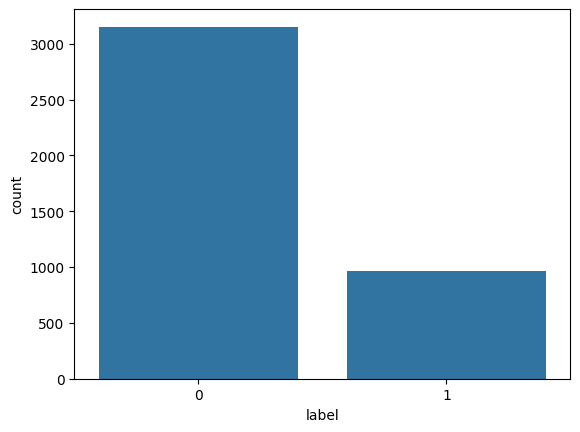

In [53]:
sns.countplot(x = 'label', data = df)

# Building Model

### Using deepmatcher

In [54]:
del df['id']

In [55]:
pos_neg_ratio = np.sum(df['label'] == 1)/ np.sum(df['label'] == 0)
pos_neg_ratio

0.3074238578680203

In [56]:
dm.data.split(df, data_dir, 'train.csv', 'valid.csv', 'test.csv',[3, 1, 1])

In [57]:
train, validation, test = dm.data.process(
    path=data_dir,
    cache='train_cache0.pth',
    train='train.csv',
    validation='valid.csv',
    test='test.csv',
    use_magellan_convention=True)

In [58]:
model = dm.MatchingModel(attr_summarizer='hybrid')
model.run_train(train, validation, epochs=3, batch_size=16, best_save_path=None, pos_neg_ratio=pos_neg_ratio)

/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


* Number of trainable parameters: 35333818
===>  TRAIN Epoch 1


/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/modules/module.py:939: UserWarning: Using non-full backward hooks on a Module that does not return a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_output. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not return a "
/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/functional.py:2741: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Finished Epoch 1 || Run Time:  251.1 | Load Time:    1.2 || F1:  91.51 | Prec:  97.09 | Rec:  86.53 || Ex/s:   9.80

===>  EVAL Epoch 1
Finished Epoch 1 || Run Time:   30.2 | Load Time:    0.4 || F1:  99.49 | Prec: 100.00 | Rec:  98.98 || Ex/s:  26.95

* Best F1: tensor(99.4872)
---------------------

===>  TRAIN Epoch 2
Finished Epoch 2 || Run Time:  299.1 | Load Time:    1.4 || F1:  99.22 | Prec: 100.00 | Rec:  98.45 || Ex/s:   8.23

===>  EVAL Epoch 2
Finished Epoch 2 || Run Time:   29.6 | Load Time:    0.4 || F1:  99.23 | Prec: 100.00 | Rec:  98.47 || Ex/s:  27.48

---------------------

===>  TRAIN Epoch 3
Finished Epoch 3 || Run Time:  265.1 | Load Time:    1.4 || F1:  99.57 | Prec: 100.00 | Rec:  99.14 || Ex/s:   9.28

===>  EVAL Epoch 3
Finished Epoch 3 || Run Time:   29.2 | Load Time:    0.4 || F1:  99.49 | Prec: 100.00 | Rec:  98.98 || Ex/s:  27.82

---------------------

Loading best model...


AttributeError: 'NoneType' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

In [ ]:
model.run_eval(test)

===>  EVAL Epoch 3
Finished Epoch 3 || Run Time:    7.3 | Load Time:    0.2 || F1:  99.75 | Prec: 100.00 | Rec:  99.50 || Ex/s: 109.90



99.74811083123424

## Usecase

In [ ]:
# test_df = pd.read_csv(os.path.join(data_dir, 'test.csv'))
# test_df = test_df.reset_index(drop=True).reset_index().rename(columns = {"index": "_id"})
# test_df.to_csv(os.path.join(data_dir, 'new_data4.csv'))
# test_df.head()

,_id,ltable_Email Address,ltable_First Name,ltable_Quickbase Record ID#,ltable_Specialty,ltable_Last Name,ltable_Status,ltable_SAP Number,ltable_Payments Made To:,ltable_Payment Currency,ltable_HCP Category,ltable_State/Region/Province,ltable_Full Name,ltable_Contact Type,ltable_National Physician ID,ltable_Country,ltable_SAP Entity Name,rtable_Email Address,rtable_First Name,rtable_Quickbase Record ID#,rtable_Specialty,rtable_Last Name,rtable_Status,rtable_SAP Number,rtable_Payments Made To:,rtable_Payment Currency,rtable_HCP Category,rtable_State/Region/Province,rtable_Full Name,rtable_Contact Type,rtable_National Physician ID,rtable_Country,rtable_SAP Entity Name,label
0,0,UNKNOWN,Masafumi,1795.0,0,Morimoto,Active,UNKNOWN,UNKNOWN,UNKNOWN,Physician,UNKNOWN,Masafumi Morimoto,HCP,UNKNOWN,Japan,UNKNOWN,jeroen.boogaarts@radboudumc.nl,Jereon,6244.0,UNKNOWN,Boogaarts,Active,UNKNOWN,UNKNOWN,EUR,Physician,UNKNOWN,Jereon Boogaarts,HCP,UNKNOWN,Netherlands,UNKNOWN,0
1,1,UNKNOWN,Johannes,966.0,UNKNOWN,Weber,Active,UNKNOWN,UNKNOWN,UNKNOWN,Physician,UNKNOWN,Johannes Weber,HCP,UNKNOWN,Switzerland,UNKNOWN,UNKNOWN,Breno,7607.0,Interventional Cardiology (IC),de Alencar Araripe Falcao,Active,UNKNOWN,UNKNOWN,BRL,Physician,Ceará,Breno de Alencar Araripe Falcao,HCP,UNKNOWN,Brazil,UNKNOWN,0
2,2,jennifer.thomas4@shhpens.org,Jennifer,1652.0,UNKNOWN,Thomas,Active,UNKNOWN,UNKNOWN,UNKNOWN,Technician,Alabama,Jennifer Thomas,HCP,UNKNOWN,United States,UNKNOWN,slee1@stlukeshealth.org,Stephen,1278.0,UNKNOWN,Lee,Active,UNKNOWN,UNKNOWN,UNKNOWN,Physician,Texas,Stephen Lee,HCP,UNKNOWN,United States,UNKNOWN,0
3,3,UNKNOWN,Kirill,1773.0,UNKNOWN,Anisimov,Active,90182379,Self,EUR,Physician,UNKNOWN,Kirill Anisimov,HCP,UNKNOWN,Russian Federation,Dr. Kirill Anisimov,UNKNOWN,Kirill,1773.0,UNKNOWN,Anisimov,Active,90182379,Self,EUR,Physician,UNKNOWN,Kirill Anisimov,HCP,UNKNOWN,Russian Federation,Dr. Kirill Anisimov,1
4,4,UNKNOWN,Mauricio,6068.0,Interventional Radiology (IR),Acosta,Active,UNKNOWN,UNKNOWN,USD,Physician,UNKNOWN,Mauricio Acosta,HCP,UNKNOWN,Colombia,UNKNOWN,brunadefina@gmail.com,Bruna,7628.0,Interventional Radiology (IR),de Fina,Active,UNKNOWN,UNKNOWN,BRL,Physician,Sao Paulo,Bruna de Fina,HCP,UNKNOWN,Brazil,UNKNOWN,0


In [ ]:
candidate = dm.data.process_unlabeled(
    path=os.path.join(data_dir, 'new_data.csv'),
    trained_model=model,
    ignore_columns=('ltable_id', 'rtable_id', 'label'))

In [ ]:
predictions = model.run_prediction(candidate, output_attributes=list(candidate.get_raw_table().columns))
predictions = predictions.rename(columns={"match_score":"confident"})

===>  PREDICT Epoch 3


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-p

Finished Epoch 3 || Run Time:    6.8 | Load Time:    0.2 || F1:   0.00 | Prec:   0.00 | Rec:   0.00 || Ex/s:   0.00



In [ ]:
selected_columns = [
 'ltable_Full Name',
 'rtable_Full Name',
 'ltable_National Physician ID',
 'rtable_National Physician ID',
 'ltable_Email Address',
 'rtable_Email Address',
 'confident', 'is_matched',
 'label']

threshold = 0.8
predictions['is_matched'] = np.where(predictions['confident'] > threshold, 1, 0)
predictions.query("(is_matched == 0) & (label == 1) ")[selected_columns].tail(20).reset_index()

,_id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,confident,is_matched,label
0,629,Donny Rodriguez,Virginia Rodriguez,UNKNOWN,UNKNOWN,donqdeedee@aol.com,donqdeedee@aol.com,0.025232,0,1


In [ ]:
predictions.query("(is_matched == 1) & (label == 0) ")[selected_columns].head(20)

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,confident,is_matched,label
_id,,,,,,,,,


In [ ]:
predictions[selected_columns].head(20)

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,confident,is_matched,label
_id,,,,,,,,,
0,Francois Cornelis,Amir Khan,UNKNOWN,UNKNOWN,UNKNOWN,akhan@communitymedical.org,0.016103,0,0
1,Garfield Lewis,Mathew Sanborn,UNKNOWN,UNKNOWN,garfield_lewisjr@yahoo.com,UNKNOWN,0.015704,0,0
2,Abdullah Shaikh,Byung hoo Moon,UNKNOWN,UNKNOWN,abdullah.shaikh@ahn.org,UNKNOWN,0.015246,0,0
3,Axel Rohr,Antonio Carlos Neves Ferreira,UNKNOWN,UNKNOWN,icketown@gmail.com,acarlostune@gmail.com,0.014860,0,0
4,Stacy Adams,Neil Rane,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0.016053,0,0
5,Luigi Simonetti,Davide Leni,UNKNOWN,UNKNOWN,bpoppi@penumbrainc.com,bpoppi@penumbrainc.com,0.850093,1,1
6,Serafino (Maria) Santonocito,Stefano Gennai,UNKNOWN,UNKNOWN,rpanzetti@penumbrainc.com,rpanzetti@penumbrainc.com,0.852213,1,1
7,Marcy Perez,Kevin Mulholland,UNKNOWN,UNKNOWN,maricelaperez77@yahoo.com,Kevcjbren@AOL.com,0.014867,0,0
8,Amy Lassiter,Aldo Paolucci,UNKNOWN,UNKNOWN,amylassiterrn@gmail.com,UNKNOWN,0.013463,0,0


## Using traditional ML approaches

In [ ]:
def build_tabular_dataloader(df,  dep_var = 'n_trips'):
    cont,cat = cont_cat_split(df, 20, dep_var=dep_var)

    np.random.seed(0)
    valid_idx = np.random.choice(df.shape[0], len(df)//10*3, replace=False)
    train_idx = range(valid_idx[-1], df.shape[0])
    

    splits = (list(train_idx),list(valid_idx))
    procs = [Categorify, FillMissing]
    to = TabularPandas(df, procs, cat, cont, y_names=dep_var, splits=splits)

    return to, cont, cat

def rf_feat_importance(m, features):
    return pd.DataFrame({'cols':features, 'imp':m.feature_importances_}).sort_values('imp', ascending=False)


In [ ]:
selected_features =[ f for f in  df.columns.tolist() if f!="id"]
regression_dataloader, cont, cat = build_tabular_dataloader(df[selected_features], dep_var='label')
xs,y = regression_dataloader.train.xs, regression_dataloader.train.y
valid_xs,valid_y = regression_dataloader.valid.xs, regression_dataloader.valid.y

In [ ]:
models = {
    'LogisticRegression': LogisticRegression(), 
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'XGBClassifier': XGBClassifier()
}

In [ ]:
validation_results = {}
for model_name, model in models.items():
    model.fit(xs, y)
    y_pred = model.predict(valid_xs)
    score =accuracy_score(valid_y,y_pred)
    validation_results[model_name] = score

/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


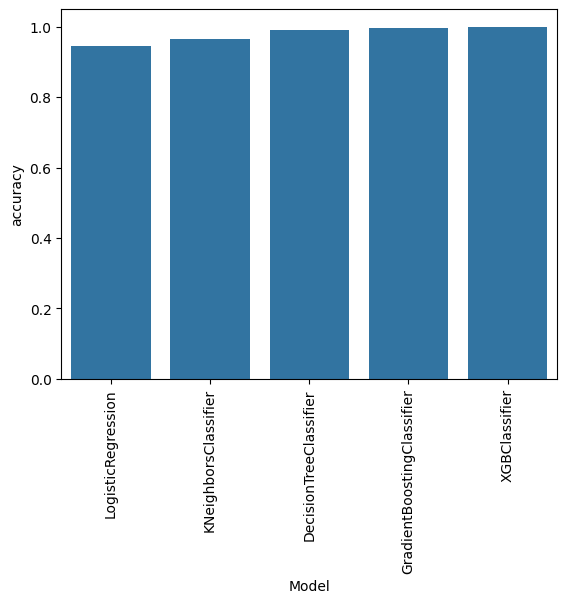

In [ ]:
validation_results = {k:v for k,v in sorted(validation_results.items(), key = lambda item: item[1])}

ax = sns.barplot(x = list(validation_results.keys()), y = list(validation_results.values()))
ax.set(xlabel='Model', ylabel='accuracy')
for item in ax.get_xticklabels():
    item.set_rotation(90)

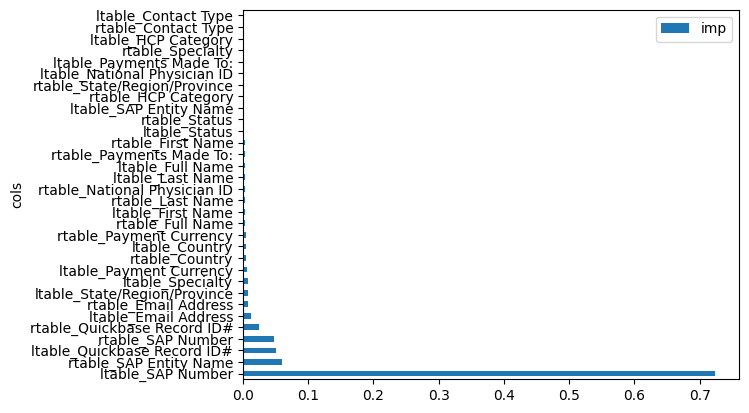

In [ ]:
fi = rf_feat_importance(models['XGBClassifier'], models['XGBClassifier'].get_booster().feature_names)
fi.plot.barh(x='cols', y='imp', rot=0)
plt.show()


# Using Magenlla 

1) Check F1 
2) Using Magenlla
3) Improve feature engineering

In [ ]:
df.head()

,id,ltable_SAP Entity Name,ltable_First Name,ltable_Country,ltable_Full Name,ltable_Contact Type,ltable_State/Region/Province,ltable_Payments Made To:,ltable_SAP Number,ltable_Payment Currency,ltable_Last Name,ltable_Specialty,ltable_Email Address,ltable_HCP Category,ltable_Status,ltable_Quickbase Record ID#,ltable_National Physician ID,rtable_SAP Entity Name,rtable_First Name,rtable_Country,rtable_Full Name,rtable_Contact Type,rtable_State/Region/Province,rtable_Payments Made To:,rtable_SAP Number,rtable_Payment Currency,rtable_Last Name,rtable_Specialty,rtable_Email Address,rtable_HCP Category,rtable_Status,rtable_Quickbase Record ID#,rtable_National Physician ID,label
674297,rtable_143,UNKNOWN,Cheol Kyu,Korea,Cheol Kyu Jung,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Jung,0,UNKNOWN,Physician,Active,-1.0,UNKNOWN,UNKNOWN,Jaroslaw,Poland,Jaroslaw Miszczuk,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Miszczuk,UNKNOWN,j.miszczuk@op.p,Physician,Active,1888.0,UNKNOWN,0
426366,ltable_164,UNKNOWN,Kristen Alexa,Singapore,Kristen Alexa Lee,HCP,UNKNOWN,UNKNOWN,UNKNOWN,USD,Lee,Interventional Radiology (IR),kristen.alexa.lee@singhealth.com.sg,Physician,Active,7123.0,UNKNOWN,UNKNOWN,Hirotoshi,Japan,Hirotoshi Imamura,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Imamura,0,UNKNOWN,Physician,Active,1796.0,UNKNOWN,0
455224,ltable_369,UNKNOWN,Michal,Poland,Michal Toborek,HCP,UNKNOWN,UNKNOWN,UNKNOWN,EUR,Toborek,UNKNOWN,toborekmichal@gmail.com,Physician,Active,5565.0,UNKNOWN,UNKNOWN,Jessica,United States,Jessica Cooke,HCP,Colorado,UNKNOWN,UNKNOWN,UNKNOWN,Cooke,UNKNOWN,UNKNOWN,Nurse,Active,2454.0,UNKNOWN,0
62504,ltable_329,UNKNOWN,Hugo,United States,Hugo Cuellar-Saenz,HCP,Louisiana,UNKNOWN,UNKNOWN,USD,Cuellar-Saenz,UNKNOWN,hcuellar77@gmail.com,Physician,Active,6060.0,1114259462,UNKNOWN,U.O.C. Neuroradiologia,Italy,U.O.C. Neuroradiologia Azienda Ospedaliera Universitaria Gaetano Martino,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Azienda Ospedaliera Universitaria Gaetano Martino,UNKNOWN,UNKNOWN,Other,Active,-1.0,UNKNOWN,0
950066,rtable_369,UNKNOWN,Johannes,Switzerland,Johannes Weber,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Weber,UNKNOWN,UNKNOWN,Physician,Active,966.0,UNKNOWN,UNKNOWN,Ronnie,United States,Ronnie Chen,HCP,California,UNKNOWN,UNKNOWN,UNKNOWN,Chen,UNKNOWN,UNKNOWN,Physician,Active,3405.0,1871883884,0


In [ ]:
K = df.drop(columns = ['id']).copy()
K = K.reset_index(drop=True).reset_index().rename(columns = {"index": "id"})
K['ltable_id'] = K['id']
K['rtable_id'] = K['id']

ltable_columns = [col for col in K.columns if col.startswith("ltable")]
rtable_columns = [col for col in K.columns if col.startswith("rtable")]

A = K[['ltable_id'] + ltable_columns]
B = K[['rtable_id'] +  rtable_columns]
columns = [col.replace("ltable_", "") for col in ltable_columns]
A.columns = ['ltable_id'] + columns
B.columns = ['rtable_id'] +  columns
S = K[['label', 'ltable_id', 'rtable_id']]

In [ ]:
A.head()

,ltable_id,SAP Entity Name,First Name,Country,Full Name,Contact Type,State/Region/Province,Payments Made To:,SAP Number,Payment Currency,Last Name,Specialty,Email Address,HCP Category,Status,Quickbase Record ID#,National Physician ID,id
0,0,UNKNOWN,Cheol Kyu,Korea,Cheol Kyu Jung,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Jung,0,UNKNOWN,Physician,Active,-1.0,UNKNOWN,0
1,1,UNKNOWN,Kristen Alexa,Singapore,Kristen Alexa Lee,HCP,UNKNOWN,UNKNOWN,UNKNOWN,USD,Lee,Interventional Radiology (IR),kristen.alexa.lee@singhealth.com.sg,Physician,Active,7123.0,UNKNOWN,1
2,2,UNKNOWN,Michal,Poland,Michal Toborek,HCP,UNKNOWN,UNKNOWN,UNKNOWN,EUR,Toborek,UNKNOWN,toborekmichal@gmail.com,Physician,Active,5565.0,UNKNOWN,2
3,3,UNKNOWN,Hugo,United States,Hugo Cuellar-Saenz,HCP,Louisiana,UNKNOWN,UNKNOWN,USD,Cuellar-Saenz,UNKNOWN,hcuellar77@gmail.com,Physician,Active,6060.0,1114259462,3
4,4,UNKNOWN,Johannes,Switzerland,Johannes Weber,HCP,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,Weber,UNKNOWN,UNKNOWN,Physician,Active,966.0,UNKNOWN,4


In [ ]:
A = A.rename(columns= {
    "State/Region/Province": "State_Region_Province",
    "Payments Made To:": "Payments Made To",
    "Quickbase Record ID#": "Quickbase Record ID"
})

B = B.rename(columns= {
    "State/Region/Province": "State_Region_Province",
    "Payments Made To:": "Payments Made To",
    "Quickbase Record ID#": "Quickbase Record ID"
})
S = S.reset_index(drop=True).reset_index().rename(columns = {"index": "id"})

In [ ]:
A.to_csv("A.csv", index=False)
B.to_csv("B.csv", index=False)
S.to_csv("S.csv", index = False)

# em.set_key(A, 'ltable_id')

A = em.read_csv_metadata('A.csv', key='ltable_id')
B = em.read_csv_metadata('B.csv', key='rtable_id')
S = em.read_csv_metadata('S.csv', key='id',ltable=A, rtable=B, fk_ltable='ltable_id', fk_rtable='rtable_id')

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


In [ ]:
# Split S into I an J
IJ = em.split_train_test(S, train_proportion=0.5, random_state=0)
I = IJ['train']
J = IJ['test']

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


In [ ]:
# Create a set of ML-matchers
dt = em.DTMatcher(name='DecisionTree', random_state=0)
svm = em.SVMMatcher(name='SVM', random_state=0)
rf = em.RFMatcher(name='RF', random_state=0)
lg = em.LogRegMatcher(name='LogReg', random_state=0)
ln = em.LinRegMatcher(name='LinReg')

In [ ]:
# Generate a set of features
F = em.get_features_for_matching(A, B, validate_inferred_attr_types=False)

In [ ]:
F.feature_name

0          SAP_Entity_Name_SAP_Entity_Name_jac_qgm_3_qgm_3
1      SAP_Entity_Name_SAP_Entity_Name_cos_dlm_dc0_dlm_dc0
2      SAP_Entity_Name_SAP_Entity_Name_jac_dlm_dc0_dlm_dc0
3                      SAP_Entity_Name_SAP_Entity_Name_mel
4                 SAP_Entity_Name_SAP_Entity_Name_lev_dist
                              ...                         
113         National_Physician_ID_National_Physician_ID_sw
114                                              id_id_exm
115                                              id_id_anm
116                                         id_id_lev_dist
117                                          id_id_lev_sim
Name: feature_name, Length: 118, dtype: object

In [ ]:
F.head()

,feature_name,left_attribute,right_attribute,left_attr_tokenizer,right_attr_tokenizer,simfunction,function,function_source,is_auto_generated
0,SAP_Entity_Name_SAP_Entity_Name_jac_qgm_3_qgm_3,SAP Entity Name,SAP Entity Name,qgm_3,qgm_3,jaccard,<function SAP_Entity_Name_SAP_Entity_Name_jac_qgm_3_qgm_3 at 0x295e939d0>,from py_entitymatching.feature.simfunctions import *\nfrom py_entitymatching.feature.tokenizers ...,True
1,SAP_Entity_Name_SAP_Entity_Name_cos_dlm_dc0_dlm_dc0,SAP Entity Name,SAP Entity Name,dlm_dc0,dlm_dc0,cosine,<function SAP_Entity_Name_SAP_Entity_Name_cos_dlm_dc0_dlm_dc0 at 0x2b48b7b80>,from py_entitymatching.feature.simfunctions import *\nfrom py_entitymatching.feature.tokenizers ...,True
2,SAP_Entity_Name_SAP_Entity_Name_jac_dlm_dc0_dlm_dc0,SAP Entity Name,SAP Entity Name,dlm_dc0,dlm_dc0,jaccard,<function SAP_Entity_Name_SAP_Entity_Name_jac_dlm_dc0_dlm_dc0 at 0x2870df9d0>,from py_entitymatching.feature.simfunctions import *\nfrom py_entitymatching.feature.tokenizers ...,True
3,SAP_Entity_Name_SAP_Entity_Name_mel,SAP Entity Name,SAP Entity Name,None,None,monge_elkan,<function SAP_Entity_Name_SAP_Entity_Name_mel at 0x2870df8b0>,from py_entitymatching.feature.simfunctions import *\nfrom py_entitymatching.feature.tokenizers ...,True
4,SAP_Entity_Name_SAP_Entity_Name_lev_dist,SAP Entity Name,SAP Entity Name,None,None,lev_dist,<function SAP_Entity_Name_SAP_Entity_Name_lev_dist at 0x2870df940>,from py_entitymatching.feature.simfunctions import *\nfrom py_entitymatching.feature.tokenizers ...,True


In [ ]:
# Convert the I into a set of feature vectors using F
H = em.extract_feature_vecs(I, 
                            feature_table=F, 
                            attrs_after='label',
                            show_progress=False)

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


In [ ]:
# Display first few rows
H.head()

,id,ltable_id,rtable_id,SAP_Entity_Name_SAP_Entity_Name_jac_qgm_3_qgm_3,SAP_Entity_Name_SAP_Entity_Name_cos_dlm_dc0_dlm_dc0,SAP_Entity_Name_SAP_Entity_Name_jac_dlm_dc0_dlm_dc0,SAP_Entity_Name_SAP_Entity_Name_mel,SAP_Entity_Name_SAP_Entity_Name_lev_dist,SAP_Entity_Name_SAP_Entity_Name_lev_sim,SAP_Entity_Name_SAP_Entity_Name_nmw,SAP_Entity_Name_SAP_Entity_Name_sw,First_Name_First_Name_jac_qgm_3_qgm_3,First_Name_First_Name_cos_dlm_dc0_dlm_dc0,First_Name_First_Name_jac_dlm_dc0_dlm_dc0,First_Name_First_Name_mel,First_Name_First_Name_lev_dist,First_Name_First_Name_lev_sim,First_Name_First_Name_nmw,First_Name_First_Name_sw,Country_Country_jac_qgm_3_qgm_3,Country_Country_cos_dlm_dc0_dlm_dc0,Country_Country_jac_dlm_dc0_dlm_dc0,Country_Country_mel,Country_Country_lev_dist,Country_Country_lev_sim,Country_Country_nmw,Country_Country_sw,Full_Name_Full_Name_jac_qgm_3_qgm_3,Full_Name_Full_Name_cos_dlm_dc0_dlm_dc0,Full_Name_Full_Name_jac_dlm_dc0_dlm_dc0,Full_Name_Full_Name_mel,Full_Name_Full_Name_lev_dist,Full_Name_Full_Name_lev_sim,Full_Name_Full_Name_nmw,Full_Name_Full_Name_sw,Contact_Type_Contact_Type_lev_dist,Contact_Type_Contact_Type_lev_sim,Contact_Type_Contact_Type_jar,Contact_Type_Contact_Type_jwn,Contact_Type_Contact_Type_exm,Contact_Type_Contact_Type_jac_qgm_3_qgm_3,State_Region_Province_State_Region_Province_jac_qgm_3_qgm_3,State_Region_Province_State_Region_Province_cos_dlm_dc0_dlm_dc0,State_Region_Province_State_Region_Province_jac_dlm_dc0_dlm_dc0,State_Region_Province_State_Region_Province_mel,State_Region_Province_State_Region_Province_lev_dist,State_Region_Province_State_Region_Province_lev_sim,State_Region_Province_State_Region_Province_nmw,State_Region_Province_State_Region_Province_sw,Payments_Made_To_Payments_Made_To_lev_dist,Payments_Made_To_Payments_Made_To_lev_sim,Payments_Made_To_Payments_Made_To_jar,Payments_Made_To_Payments_Made_To_jwn,Payments_Made_To_Payments_Made_To_exm,Payments_Made_To_Payments_Made_To_jac_qgm_3_qgm_3,SAP_Number_SAP_Number_lev_dist,SAP_Number_SAP_Number_lev_sim,SAP_Number_SAP_Number_jar,SAP_Number_SAP_Number_jwn,SAP_Number_SAP_Number_exm,SAP_Number_SAP_Number_jac_qgm_3_qgm_3,Payment_Currency_Payment_Currency_lev_dist,Payment_Currency_Payment_Currency_lev_sim,Payment_Currency_Payment_Currency_jar,Payment_Currency_Payment_Currency_jwn,Payment_Currency_Payment_Currency_exm,Payment_Currency_Payment_Currency_jac_qgm_3_qgm_3,Last_Name_Last_Name_jac_qgm_3_qgm_3,Last_Name_Last_Name_cos_dlm_dc0_dlm_dc0,Last_Name_Last_Name_jac_dlm_dc0_dlm_dc0,Last_Name_Last_Name_mel,Last_Name_Last_Name_lev_dist,Last_Name_Last_Name_lev_sim,Last_Name_Last_Name_nmw,Last_Name_Last_Name_sw,Specialty_Specialty_jac_qgm_3_qgm_3,Specialty_Specialty_cos_dlm_dc0_dlm_dc0,Specialty_Specialty_jac_dlm_dc0_dlm_dc0,Specialty_Specialty_mel,Specialty_Specialty_lev_dist,Specialty_Specialty_lev_sim,Specialty_Specialty_nmw,Specialty_Specialty_sw,Email_Address_Email_Address_jac_qgm_3_qgm_3,Email_Address_Email_Address_cos_dlm_dc0_dlm_dc0,Email_Address_Email_Address_jac_dlm_dc0_dlm_dc0,Email_Address_Email_Address_mel,Email_Address_Email_Address_lev_dist,Email_Address_Email_Address_lev_sim,Email_Address_Email_Address_nmw,Email_Address_Email_Address_sw,HCP_Category_HCP_Category_jac_qgm_3_qgm_3,HCP_Category_HCP_Category_cos_dlm_dc0_dlm_dc0,HCP_Category_HCP_Category_jac_dlm_dc0_dlm_dc0,HCP_Category_HCP_Category_mel,HCP_Category_HCP_Category_lev_dist,HCP_Category_HCP_Category_lev_sim,HCP_Category_HCP_Category_nmw,HCP_Category_HCP_Category_sw,Status_Status_lev_dist,Status_Status_lev_sim,Status_Status_jar,Status_Status_jwn,Status_Status_exm,Status_Status_jac_qgm_3_qgm_3,Quickbase_Record_ID_Quickbase_Record_ID_exm,Quickbase_Record_ID_Quickbase_Record_ID_anm,Quickbase_Record_ID_Quickbase_Record_ID_lev_dist,Quickbase_Record_ID_Quickbase_Record_ID_lev_sim,National_Physician_ID_National_Physician_ID_jac_qgm_3_qgm_3,National_Physician_ID_National_Physician_ID_cos_dlm_dc0_dlm_dc0,National_Physician_ID_National_Physician_ID_jac_dlm_dc0_dlm_dc0,National_Physician

In [ ]:
# Check if the feature vectors contain missing values
# A return value of True means that there are missing values
any(pd.notnull(H))

True

In [ ]:
# Impute feature vectors with the mean of the column values.
H = em.impute_table(H, 
                exclude_attrs=['id', 'ltable_id', 'rtable_id', 'label'],
                strategy='mean')

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/matcher/matcherutils.py:224: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  imp.statistics_[pd.np.isnan(imp.statistics_)] = val_all_nans


In [ ]:
# Select the best ML matcher using CV
result = em.select_matcher([dt, rf, svm, ln, lg], table=H, 
        exclude_attrs=['id', 'ltable_id', 'rtable_id', 'label'],
        k=5,
        target_attr='label', metric_to_select_matcher='f1', random_state=0)
result['cv_stats']

/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/lin

,Matcher,Average precision,Average recall,Average f1
0,DecisionTree,0.993075,0.990315,0.991678
1,RF,0.998925,0.988072,0.993447
2,SVM,0.998925,0.989246,0.994055
3,LinReg,0.997783,0.977754,0.987660
4,LogReg,0.993112,0.991655,0.992373


In [ ]:
result['drill_down_cv_stats']['precision']


,Name,Matcher,Num folds,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean score
0,DecisionTree,<py_entitymatching.matcher.dtmatcher.DTMatcher object at 0x295af6730>,5,1.000000,0.987421,0.993827,1.000000,0.984127,0.993075
1,RF,<py_entitymatching.matcher.rfmatcher.RFMatcher object at 0x295af6fd0>,5,1.000000,1.000000,1.000000,1.000000,0.994624,0.998925
2,SVM,<py_entitymatching.matcher.svmmatcher.SVMMatcher object at 0x295af60a0>,5,1.000000,1.000000,1.000000,1.000000,0.994624,0.998925
3,LinReg,<py_entitymatching.matcher.linregmatcher.LinRegMatcher object at 0x295b01bb0>,5,1.000000,1.000000,1.000000,0.994350,0.994565,0.997783
4,LogReg,<py_entitymatching.matcher.logregmatcher.LogRegMatcher object at 0x295af6fa0>,5,0.993289,0.993671,1.000000,0.994475,0.984127,0.993112


In [ ]:
result['drill_down_cv_stats']['recall']

,Name,Matcher,Num folds,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean score
0,DecisionTree,<py_entitymatching.matcher.dtmatcher.DTMatcher object at 0x295af6730>,5,0.993289,0.987421,0.981707,0.994505,0.994652,0.990315
1,RF,<py_entitymatching.matcher.rfmatcher.RFMatcher object at 0x295af6fd0>,5,1.000000,0.974843,0.981707,0.994505,0.989305,0.988072
2,SVM,<py_entitymatching.matcher.svmmatcher.SVMMatcher object at 0x295af60a0>,5,0.993289,0.987421,0.981707,0.994505,0.989305,0.989246
3,LinReg,<py_entitymatching.matcher.linregmatcher.LinRegMatcher object at 0x295b01bb0>,5,0.986577,0.974843,0.981707,0.967033,0.978610,0.977754
4,LogReg,<py_entitymatching.matcher.logregmatcher.LogRegMatcher object at 0x295af6fa0>,5,0.993289,0.987421,0.993902,0.989011,0.994652,0.991655


In [ ]:
result['drill_down_cv_stats']['f1']

,Name,Matcher,Num folds,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean score
0,DecisionTree,<py_entitymatching.matcher.dtmatcher.DTMatcher object at 0x295af6730>,5,0.996633,0.987421,0.987730,0.997245,0.989362,0.991678
1,RF,<py_entitymatching.matcher.rfmatcher.RFMatcher object at 0x295af6fd0>,5,1.000000,0.987261,0.990769,0.997245,0.991957,0.993447
2,SVM,<py_entitymatching.matcher.svmmatcher.SVMMatcher object at 0x295af60a0>,5,0.996633,0.993671,0.990769,0.997245,0.991957,0.994055
3,LinReg,<py_entitymatching.matcher.linregmatcher.LinRegMatcher object at 0x295b01bb0>,5,0.993243,0.987261,0.990769,0.980501,0.986523,0.987660
4,LogReg,<py_entitymatching.matcher.logregmatcher.LogRegMatcher object at 0x295af6fa0>,5,0.993289,0.990536,0.996942,0.991736,0.989362,0.992373


## Debug X (Random Forest)

In [ ]:
# Split H into P and Q
PQ = em.split_train_test(H, train_proportion=0.5, random_state=0)
P = PQ['train']
Q = PQ['test']

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


In [ ]:
# Debug RF matcher using GUI
em.vis_debug_rf(rf, P, Q, 
        exclude_attrs=['id', 'ltable_id', 'rtable_id', 'label'],
        target_attr='label')

: 